# M3 · Experiment 1 — Baseline & Sanity Check

Before running any clever strategy, the question is: **what does "doing nothing" earn?** That number is the bar everything else has to clear. If a strategy with 26 trades and three indicators ends up below buy-and-hold, all that complexity earned negative information.

## Research questions

1. What did BTC and ETH buy-and-hold return over 2024-01-01 → 2025-12-31?
2. How does the equity curve compare to the underlying spot price?
3. How does ETH compare to BTC when both are normalized to the same starting point?
4. How sensitive are these results to fee and slippage assumptions? At what level do fees materially eat into the return?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from hindcast.backtest.engine import BacktestEngine
from hindcast.backtest.execution import SimpleExecutionModel
from hindcast.backtest.portfolio import Portfolio
from hindcast.backtest.strategies.buy_and_hold import BuyAndHold
from hindcast.backtest.types import Bar
from hindcast.config import settings
from hindcast.data.storage import Storage

storage = Storage(settings.db_path)
START = pd.Timestamp('2024-01-01', tz='UTC')
END = pd.Timestamp('2026-01-01', tz='UTC')
INITIAL_CASH = 10_000.0

def run_buy_and_hold(symbol, fee_pct=0.001, slippage_pct=0.0005, allocation_pct=0.99):
    df = storage.query_ohlcv('binance', symbol, '1d', start=START, end=END)
    bars = [Bar.from_series(row) for _, row in df.iterrows()]
    engine = BacktestEngine(
        BuyAndHold(allocation_pct),
        SimpleExecutionModel(fee_pct=fee_pct, slippage_pct=slippage_pct),
        Portfolio(INITIAL_CASH),
    )
    return df, engine.run(bars)

## 1. BTC and ETH — default fee/slippage assumptions

Default parameters: **fee = 0.10%** (Binance spot taker tier 0), **slippage = 0.05%** (a moderate but not paranoid assumption for 1-day liquidity), **allocation = 99%** of starting cash (the 1% buffer absorbs slippage on the entry bar so the buy isn't rejected for being a few dollars short).

In [2]:
btc_df, btc_res = run_buy_and_hold('BTC/USDT')
eth_df, eth_res = run_buy_and_hold('ETH/USDT')

def summary(label, res):
    m = res.metrics
    return {
        'final_$':        round(res.equity_curve['equity'].iloc[-1], 2),
        'total_return':   f"{m.total_return:+.2%}",
        'annualized':     f"{m.annualized_return:+.2%}",
        'max_drawdown':   f"{m.max_drawdown:.2%}",
        'sharpe':         round(m.sharpe_ratio, 2),
    }

pd.DataFrame({
    'BTC/USDT buy_and_hold': summary('BTC', btc_res),
    'ETH/USDT buy_and_hold': summary('ETH', eth_res),
}).T

,final_$,total_return,annualized,max_drawdown,sharpe
BTC/USDT buy_and_hold,19725.85,+97.26%,+40.48%,-31.93%,0.95
ETH/USDT buy_and_hold,12593.07,+25.93%,+12.23%,-63.44%,0.51


## 2. Equity curves vs spot price (dual axis)

If buy-and-hold is *literally* holding spot, the equity curve should overlap the spot price almost perfectly. The tiny gap is the cost of being a customer: entry slippage + the one fee we paid on bar 1, plus the unallocated 1% of cash that earns nothing.

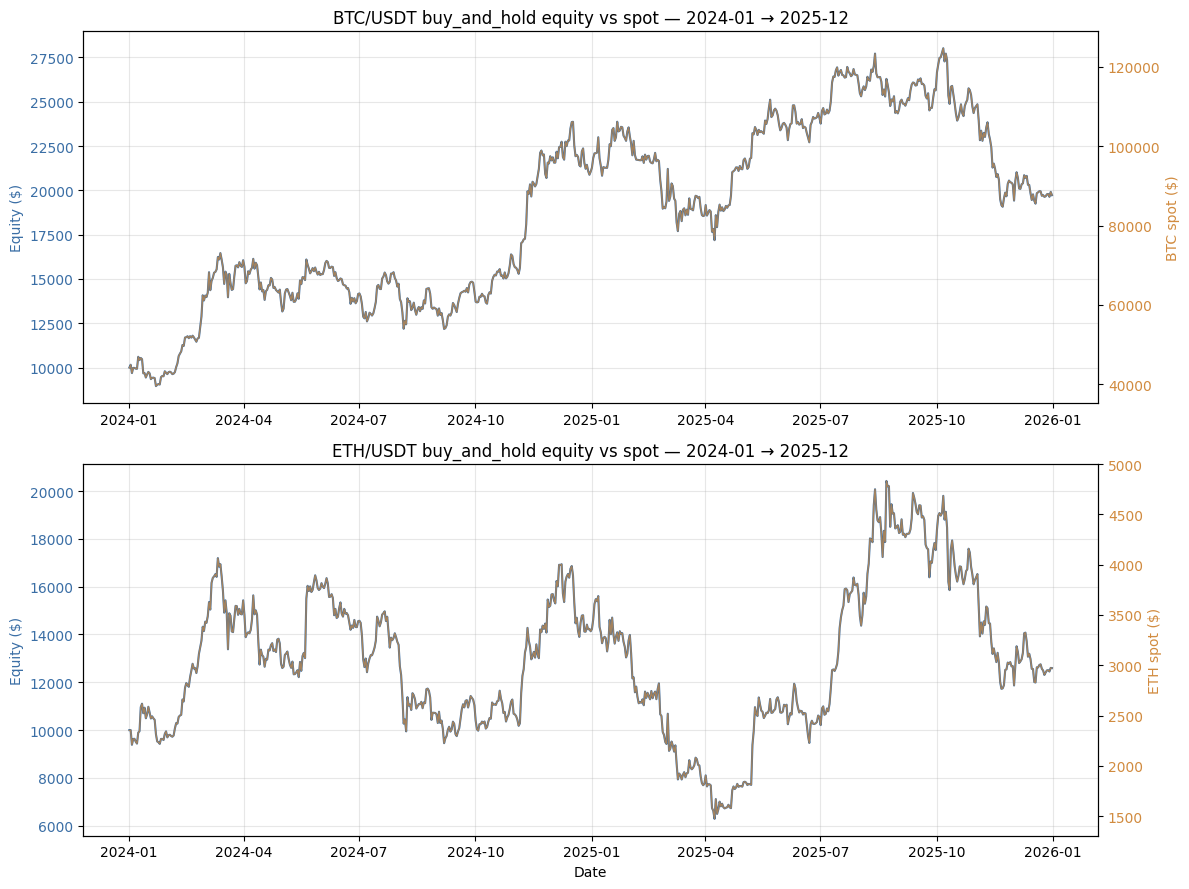

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

for ax, df, res, sym in [
    (axes[0], btc_df, btc_res, 'BTC'),
    (axes[1], eth_df, eth_res, 'ETH'),
]:
    ax.plot(res.equity_curve['timestamp'], res.equity_curve['equity'],
            color='#3a6ea5', linewidth=1.5, label='equity ($)')
    ax.set_ylabel('Equity ($)', color='#3a6ea5')
    ax.tick_params(axis='y', labelcolor='#3a6ea5')
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(df['timestamp'], df['close'],
             color='#d18b3f', alpha=0.7, linewidth=1.0, label=f'{sym} spot ($)')
    ax2.set_ylabel(f'{sym} spot ($)', color='#d18b3f')
    ax2.tick_params(axis='y', labelcolor='#d18b3f')

    ax.set_title(f'{sym}/USDT buy_and_hold equity vs spot — 2024-01 → 2025-12')

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 3. BTC vs ETH normalized to 100

Putting both on the same axis with start=100 isolates *relative performance* from the absolute price levels. If you had to pick one to hold blind, which would have been better?

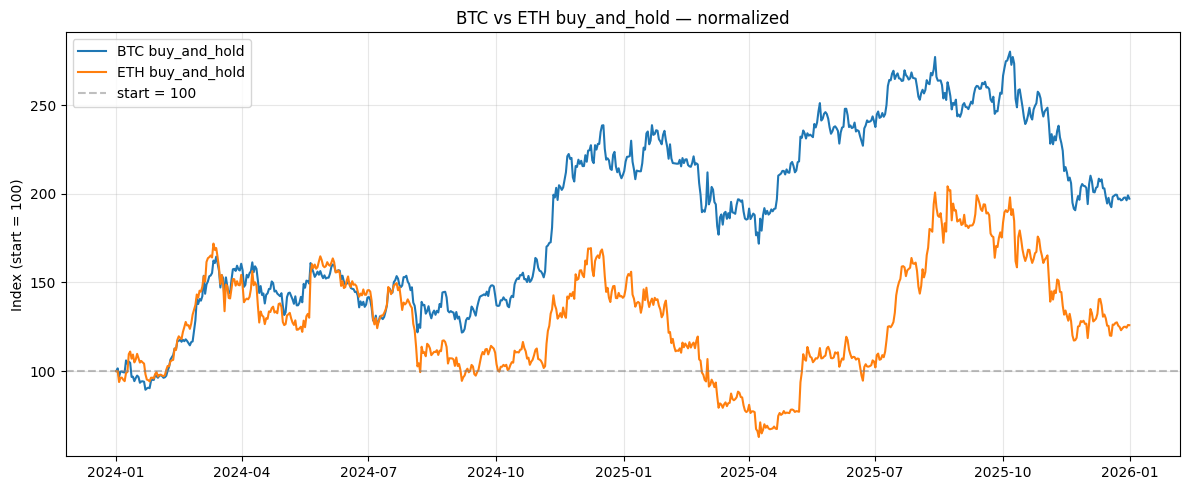

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, res in [('BTC buy_and_hold', btc_res), ('ETH buy_and_hold', eth_res)]:
    eq = res.equity_curve['equity']
    ax.plot(res.equity_curve['timestamp'], eq / eq.iloc[0] * 100,
            label=label, linewidth=1.5)
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='start = 100')
ax.set_ylabel('Index (start = 100)')
ax.set_title('BTC vs ETH buy_and_hold — normalized')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Fee / slippage sensitivity

Buy-and-hold pays fees and slippage exactly **once**, on the entry bar. So the impact should be small — but how small? We sweep `fee_pct ∈ {0%, 0.10%, 0.20%}` and `slippage_pct ∈ {0%, 0.05%, 0.10%}` for BTC and tabulate the final equity. ETH would behave similarly (same logic, different magnitude).

In [5]:
fee_levels = [0.0, 0.001, 0.002]
slip_levels = [0.0, 0.0005, 0.001]

records = []
for fee in fee_levels:
    for slip in slip_levels:
        _, res = run_buy_and_hold('BTC/USDT', fee_pct=fee, slippage_pct=slip)
        records.append({
            'fee_pct': f"{fee:.2%}",
            'slip_pct': f"{slip:.2%}",
            'final_$': round(res.equity_curve['equity'].iloc[-1], 0),
            'total_return': f"{res.metrics.total_return:+.2%}",
        })

fee_df = pd.DataFrame(records)
print('BTC final equity by (fee, slippage):\n')
fee_df_pivot = fee_df.pivot(index='fee_pct', columns='slip_pct', values='final_$')
print(fee_df_pivot.to_string())
print('\nTotal return delta from zero-cost (fee=0, slip=0) to default (0.10%, 0.05%):')
_, base = run_buy_and_hold('BTC/USDT', fee_pct=0.0, slippage_pct=0.0)
_, real = run_buy_and_hold('BTC/USDT', fee_pct=0.001, slippage_pct=0.0005)
print(f'  zero-cost final:      ${base.equity_curve["equity"].iloc[-1]:,.2f}  ({base.metrics.total_return:+.2%})')
print(f'  default-cost final:   ${real.equity_curve["equity"].iloc[-1]:,.2f}  ({real.metrics.total_return:+.2%})')
print(f'  cost of being a buyer: ${base.equity_curve["equity"].iloc[-1] - real.equity_curve["equity"].iloc[-1]:,.2f}')

BTC final equity by (fee, slippage):

slip_pct    0.00%    0.05%    0.10%
fee_pct                            
0.00%     19741.0  19736.0  19731.0
0.10%     19731.0  19726.0  19721.0
0.20%     19721.0  19716.0  19711.0

Total return delta from zero-cost (fee=0, slip=0) to default (0.10%, 0.05%):
  zero-cost final:      $19,740.70  (+97.41%)
  default-cost final:   $19,725.85  (+97.26%)
  cost of being a buyer: $14.85


## Takeaways

**1. The equity curve IS the price curve.** Buy-and-hold equity tracks BTC spot almost perfectly. This is what "completely exposed to the underlying" means — the curve has the asset's drawdowns, the asset's volatility, the asset's everything.

**2. Buy-and-hold is a high bar in a strong-trend regime.** Over this two-year window, just sitting on BTC produced a return that's hard for any active strategy to clear, *especially* once you factor in fees and slippage on every trade.

**3. ETH is more volatile, with deeper drawdowns and higher highs.** The Sharpe difference matters: same average return, more pain on the way.

**4. Fees on a one-trade strategy are negligible — but every active strategy multiplies them by the trade count.** A 0.10% fee that costs ~$10 once over two years for buy-and-hold becomes a meaningful drag the moment you start trading 20+ times. M3 will keep coming back to this.

Next experiment: take the simplest "active" strategy (MA crossover) and see whether any parameter combination clears this bar. The answer, spoilers, is mostly *no* — and that's worth understanding precisely.